In [6]:
# Import relevant packages
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, box, shape
import contextily as cx
import os

In [2]:
import rasterio
from rasterio.plot import show
from rasterio.mask import mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.features import shapes
from scipy.ndimage import label

##### Read in all geojson files of India administrative boundaries from HDX India Subnational Boundaries and extract those relevant for West Bengal.

In [3]:
# Define a function to read in geoJSON shape files for administrative boundaries

def read_geojson_file(filepath):
    gdf = gpd.read_file(filepath)

    # Convert it to relevant coordinate system for India
    gdf.crs = 'epsg:4326'

    # Drop irrelevant columns for data processing
    if gdf.columns.isin(['shapeISO', 'shapeID', 'shapeGroup']).any():  
        gdf = gdf.drop(columns=['shapeISO', 'shapeID', 'shapeGroup'])   
            
    return gdf

In [ ]:
# Read in all India administrative boundaries
data_dir = "../data/raw/adm"

# Read in all state boundaries & rename column
ind_adm1 = read_geojson_file(f"{data_dir}/IND-ADM1.geojson")
ind_adm1 = ind_adm1.rename(columns={'shapeName':'state'})

# Read in all district boundaries & rename column
ind_adm2 = read_geojson_file(f"{data_dir}/IND-ADM2.geojson")
ind_adm2 = ind_adm2.rename(columns={'shapeName':'district'})

# Read in all sub-district boundaries & rename column
ind_adm3 = read_geojson_file(f"{data_dir}/IND-ADM3.geojson")
ind_adm3 = ind_adm3.rename(columns={'shapeName':'sub_district'})

# Read in all block boundaries & rename column
ind_adm4 = read_geojson_file(f"{data_dir}/IND-ADM4.geojson")
ind_adm4 = ind_adm4.rename(columns={'shapeName':'block'})

In [9]:
# Extract the West Bengal state boundary from ADM1
west_bengal = ind_adm1[ind_adm1['state'] == 'West Bengal'].to_crs(ind_adm2.crs)

# Write out the West Bengal state boundary as geoJSON file
west_bengal.to_file('../data/processed/west-bengal.geojson', driver='GeoJSON')

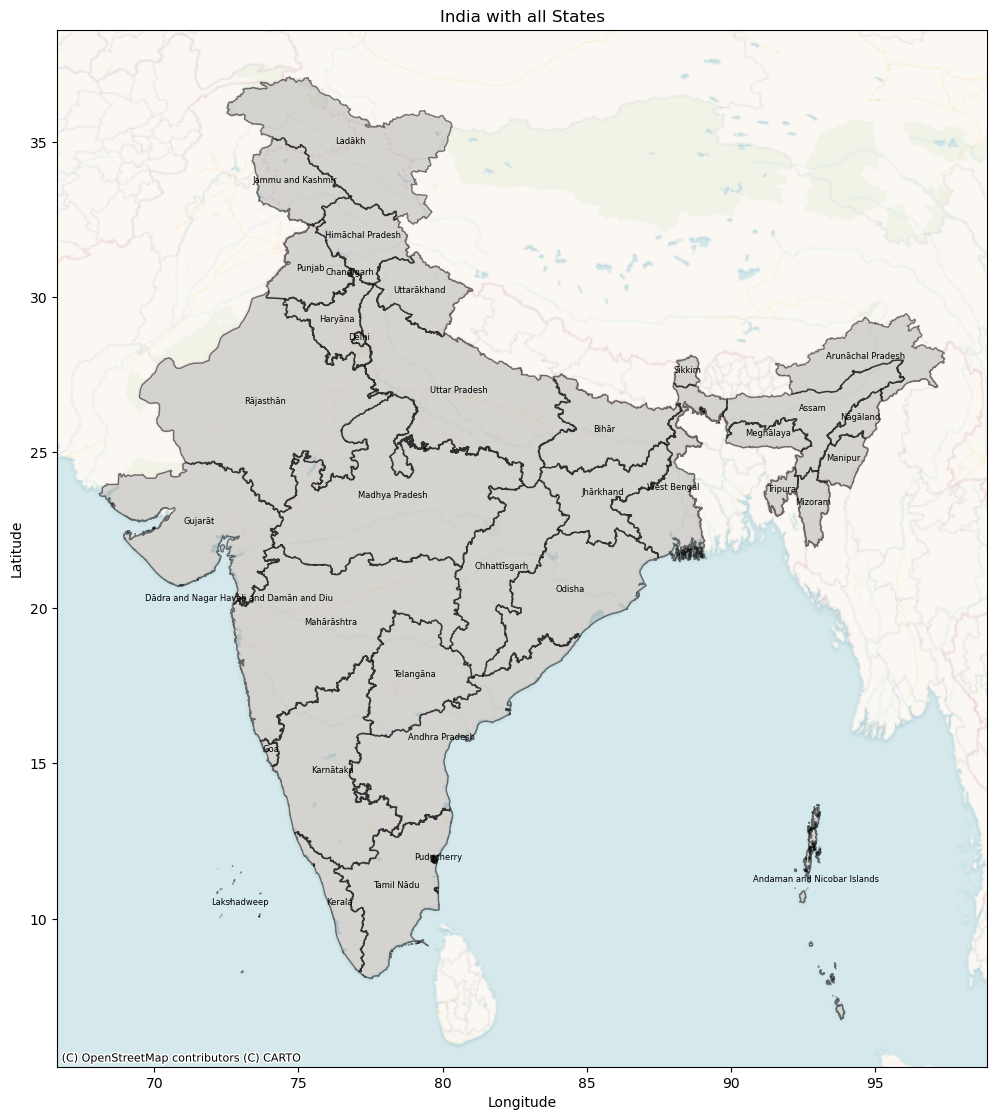

In [10]:
# Plot West Bengal State with all division boundaries
fig, ax = plt.subplots(figsize=(12,15))
ind_adm1.plot(ax=ax, color='gray', alpha=0.3)
ind_adm1.boundary.plot(ax=ax, color='black', alpha=0.5, linewidth=1)

# Add a basemap
cx.add_basemap(ax, crs=ind_adm1.crs, source=cx.providers.CartoDB.VoyagerNoLabels)

# Add district lables
for idx, row in ind_adm1.iterrows():
    plt.text(row.geometry.centroid.x, row.geometry.centroid.y, s=row['state'], 
             fontsize=6, ha='center', color='black')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('India with all States')
plt.show()

In [11]:
# Extract the districts in West Bengal
wb_districts = gpd.clip(ind_adm2, mask=west_bengal)

# Write out the district boundaries as a geoJSON file
wb_districts.to_file('../data/processed/west-bengal-districts.geojson', driver='GeoJSON')

In [13]:
# Extract the sub-districts in West Bengal
wb_subdistricts = gpd.clip(ind_adm3, mask=west_bengal)

# Write out the sub-district boundaries as a geoJSON file
wb_subdistricts.to_file('../data/processed/west-bengal-subdistricts.geojson', driver='GeoJSON')

In [15]:
# Extract the blocks in West Bengal
wb_blocks = gpd.clip(ind_adm4, mask=west_bengal)

# Write out the block boundaries as a geoJSON file
wb_blocks.to_file('../data/processed/west-bengal-blocks.geojson', driver='GeoJSON')

##### Read in West Bengal Regional Transport Organization (RTO) data on 3W vehicle registrations & convert to geojson

In [17]:
# Define a function to process latitude and longitude coordinate data into point geometry and create a corresponding geodataframe
def geometry_process(filepath):
    data = pd.read_excel(filepath)

    # Convert latitude and longitude data to Point data to be used to create a geodataframe.
    points = data.apply(lambda row: Point(row.Long, row.Lat), axis=1)

    # Create a new geodataframe using converted geometry points
    gdf = gpd.GeoDataFrame(data, geometry=points)
    gdf.crs = 'epsg:4326'

    return gdf

In [22]:
# Read in West Bengal RTO data and write out to geoJSOn file.
wb_rto = geometry_process('../data/raw/WB_RTO_vehicle_count.xlsx')
wb_rto.to_file('../data/processed/west-bengal-rto.geojson', driver='GeoJSON')

In [24]:
# Read in West Bengal RTO data for electric 3Ws (e-rickshaws, E3Ws-Passenger, E3W-Goods) and write out to GeoJSON file
wb_rto_3w = geometry_process('../data/raw/wb-rto-3w.xlsx')
wb_rto_3w.to_file('../data/processed/west-bengal-rto-threewheeler.geojson', driver='GeoJSON')

##### Process population data tiff file and extract for West Bengal (100 m resolution)

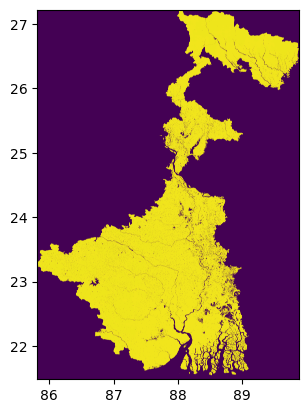

In [25]:
# Define population image file
imagefile = '../data/raw/ind_ppp_2020.tif'

with rasterio.open(imagefile) as raster:

    # Define the transform and new dimensions for reprojecting
    transform, width, height = calculate_default_transform(
        raster.crs, 'EPSG:4326', raster.width, raster.height, *raster.bounds)

    # Create an array to hold the reprojected data
    reprojected_data = np.empty((height, width), dtype=np.float32)

    # Reproject the raster to EPSG:4326
    reproject(
        source=raster.read(1),
        destination=reprojected_data,
        src_transform=raster.transform,
        src_crs=raster.crs,
        dst_transform=transform,
        dst_crs='EPSG:4326',
        resampling=Resampling.nearest)
    
    # Read the first band of data for raster
    ind_pop = raster

    # Create a clip of only population data for West Bengal using a mask
    west_bengal_pop, west_bengal_transform = mask(ind_pop, west_bengal.geometry, crop=True)

show(west_bengal_pop, transform=west_bengal_transform)

# Write out extracted West Bengal population data as new tiff file
with rasterio.open(
    '../data/processed/west_bengal_pop.tif', 
    'w', 
    driver='GTiff', 
    height=west_bengal_pop.shape[1], 
    width=west_bengal_pop.shape[2], 
    count=1, 
    dtype=west_bengal_pop.dtype, 
    crs='EPSG:4326', 
    transform=west_bengal_transform,
) as dst:
    dst.write(west_bengal_pop[0], 1)

##### Process Relative Wealth Index (RWI) file and extract data for West Bengal

In [27]:
ind_pak_rwi = pd.read_csv('../data/raw/ind_pak_relative_wealth_index.csv')

# Convert latitude and longitude (X and Y) data to Point data to be used to create a geodataframe.
rwi_points = ind_pak_rwi.apply(lambda row: Point(row.longitude, row.latitude), axis=1)

# Create a new geodataframe using converted geometry points
rwi = gpd.GeoDataFrame(ind_pak_rwi, geometry = rwi_points)
rwi.crs = 'epsg:4326'
rwi.head()

# Extract the points for West Bengal and save to output file
wb_rwi = gpd.clip(rwi, mask=west_bengal).reset_index(drop=True)

# Write out the extracted RWI points to a geojson file
wb_rwi.to_file('../data/processed/west-bengal-RWI.geojson', driver='GeoJSON')

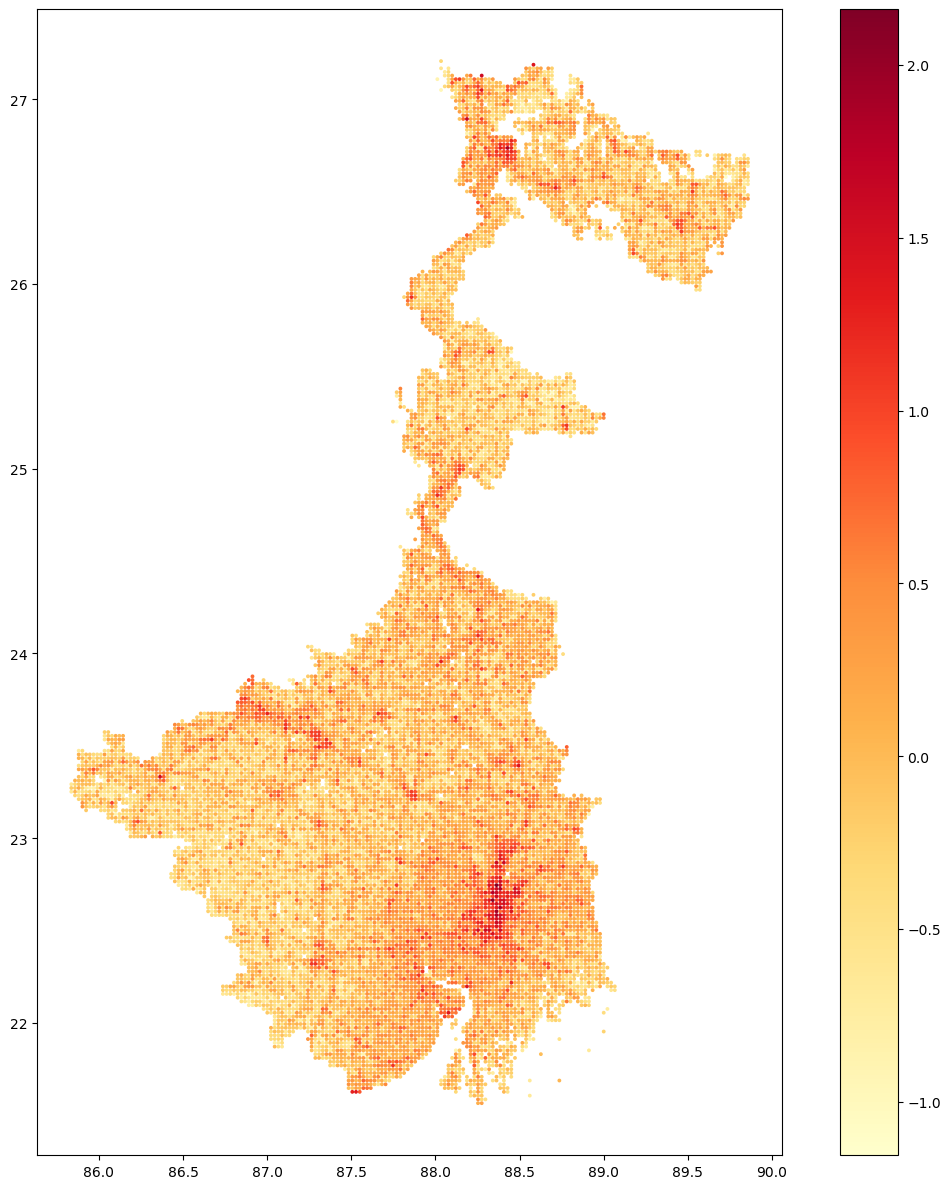

In [28]:
# Plot the relative wealth index data as point geometry for West Bengal
fig, ax = plt.subplots(figsize=(12,12))
wb_rwi.plot(ax=ax, column='rwi', markersize=3, cmap='YlOrRd', legend=True)
plt.tight_layout()